In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Load the certified dataset
df = pd.read_csv('../data/annotated/final_labeled_fintech_data.csv')

# Quick look to confirm everything is intact
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (572, 2)


,cleaned_review,sentiment
0,very good,Positive
1,i love everything about your banking system .,Positive
2,good app,Positive
3,it's very cool,Positive
4,fast and reliable tested and trusted to use fo...,Positive


C:\Users\Cobekpa\AppData\Local\Temp\ipykernel_11472\3048592618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])


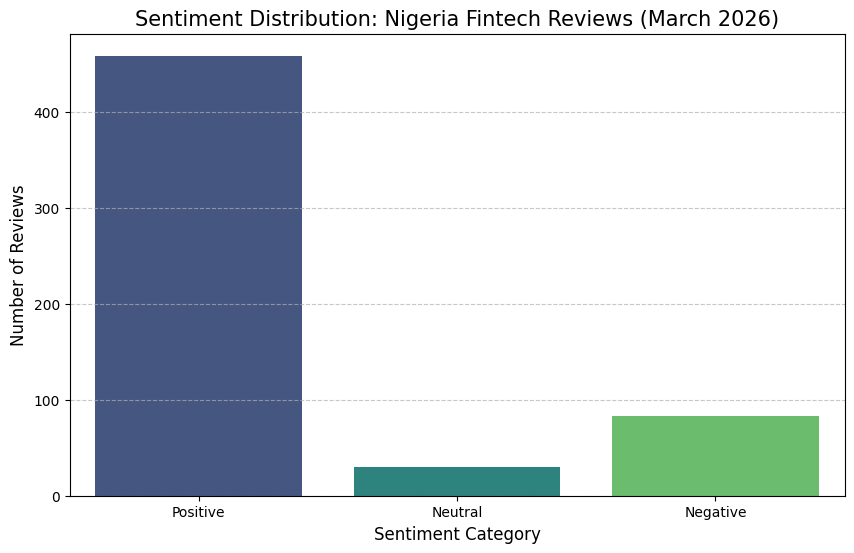

Percentage Breakdown:
sentiment
Positive    80.244755
Negative    14.510490
Neutral      5.244755
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(10, 6))
# Using a professional color palette
sns.countplot(data=df, x='sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])

plt.title('Sentiment Distribution: Nigeria Fintech Reviews (March 2026)', fontsize=15)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Displaying the exact percentage breakdown
print("Percentage Breakdown:")
print(df['sentiment'].value_counts(normalize=True) * 100)

- The "Dominance of Convenience": High positive sentiment (80%) often reflects the high adoption of "Instant Payment" features. In 2026, apps like OPay, Moniepoint, and Kuda have mastered the "frictionless transfer," which users value above almost everything else.

- The "Vocal Minority" (14% Negative): Even though it’s a smaller percentage, these are usually high-impact issues. In the Nigerian context, these are likely tied to failed transaction excessive charges and payments for services not intended to attract such fees.

- The "Neutral" Gap (5%): A low neutral count means people in this market are rarely "indifferent." They either love the speed or are frustrated by a specific failure.

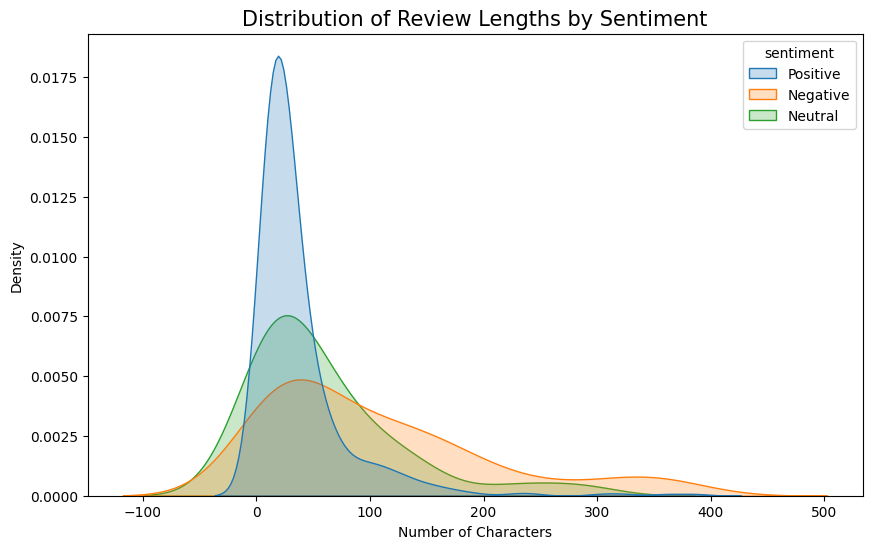

In [3]:
# Create a helper column for character count
df['review_len'] = df['cleaned_review'].apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='review_len', hue='sentiment', fill=True, common_norm=False)
plt.title('Distribution of Review Lengths by Sentiment', fontsize=15)
plt.xlabel('Number of Characters')
plt.show()

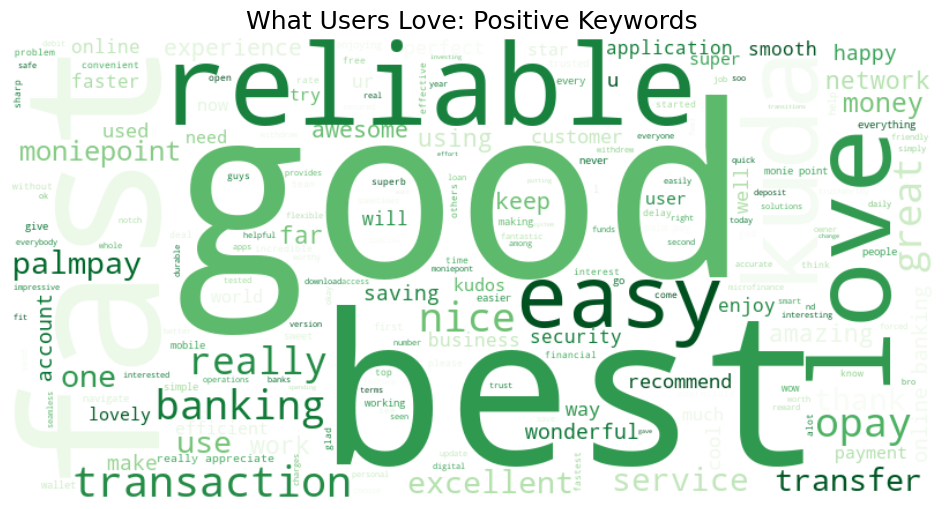

In [4]:
# Filter for positive reviews
pos_text = " ".join(review for review in df[df['sentiment'] == 'Positive']['cleaned_review'])

# Adding custom stopwords for the Nigerian context if needed
custom_stops = set(STOPWORDS)
custom_stops.update(["app", "bank", "fintech", "nigeria"]) 

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stops, colormap='Greens').generate(pos_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('What Users Love: Positive Keywords', fontsize=18)
plt.axis('off')
plt.show()

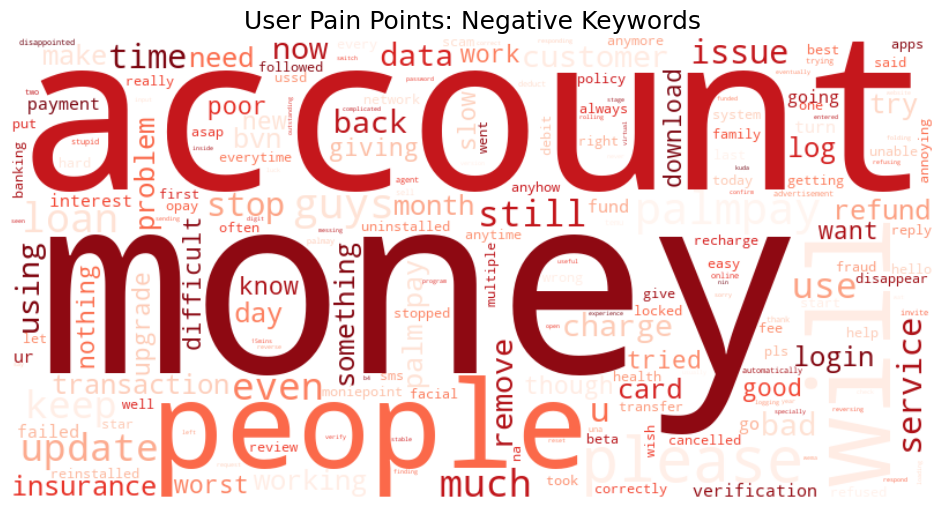

In [5]:
# Filter for negative reviews
neg_text = " ".join(review for review in df[df['sentiment'] == 'Negative']['cleaned_review'])

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', 
                          stopwords=custom_stops, colormap='Reds').generate(neg_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('User Pain Points: Negative Keywords', fontsize=18)
plt.axis('off')
plt.show()

C:\Users\Cobekpa\AppData\Local\Temp\ipykernel_11472\3536881959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sentiment', palette=['#2ecc71', '#e74c3c', '#f1c40f'],


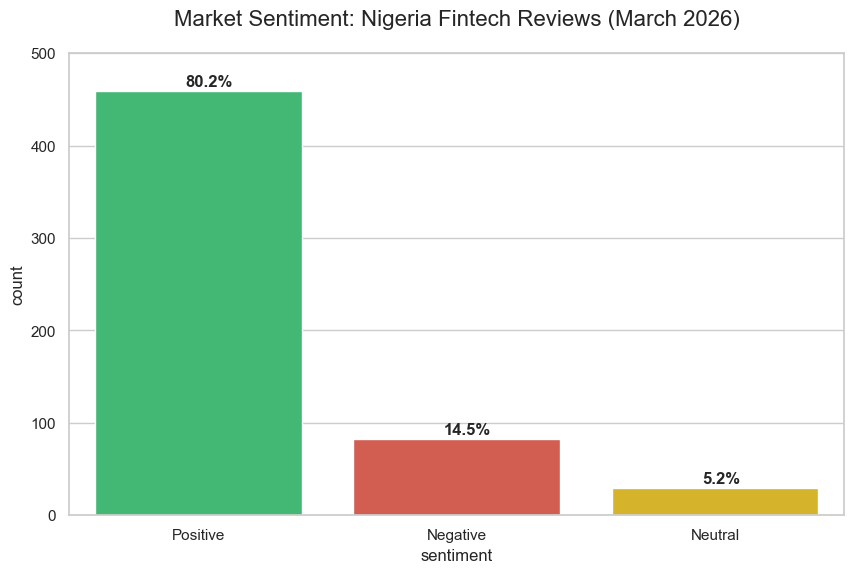

In [6]:
# 1. Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Create the bar plot
ax = sns.countplot(data=df, x='sentiment', palette=['#2ecc71', '#e74c3c', '#f1c40f'], 
                   order=['Positive', 'Negative', 'Neutral'])

# 3. Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 5
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Market Sentiment: Nigeria Fintech Reviews (March 2026)', fontsize=16, pad=20)
plt.ylim(0, 500) # Adjust based on your max count
plt.show()